<a id="top"></a>

# Index

- [1. Why is important the online service vs call service](#why-online-vs-call)
- [2. Who are the primary clients using this online process?](#primary-clients)
  - [2.1 Age distribution for primary vs other clients](#age-distribution)
  - [2.2 Tenure distribution for primary vs other clients](#tenure-distribution)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the processed dataset
df = pd.read_csv('F:/Ironhack/vanguard-ab-test/Data/Processed/df_final_merged_processed.csv')

### 1. Why is important the online service vs call service <a id="why-online-vs-call"></a>

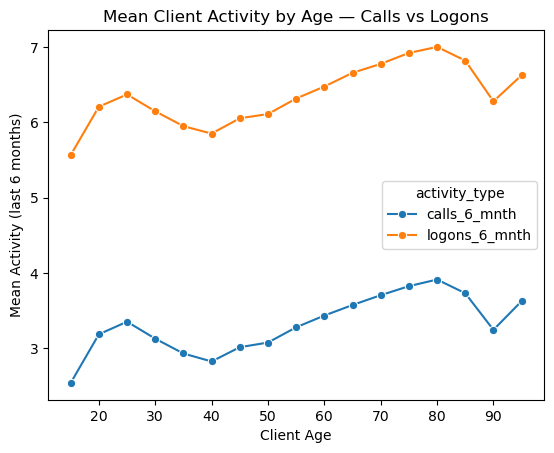

In [3]:
# Create age bins
df["age_decade"] = (df["clnt_age"] // 5) * 5

# Group by age and calculate mean activity
activity_by_age = (
    df.groupby("age_decade")[["calls_6_mnth", "logons_6_mnth"]]
      .mean()
      .reset_index()
)

# Melt into long format for easier plotting
activity_melted = activity_by_age.melt(
    id_vars="age_decade",
    value_vars=["calls_6_mnth", "logons_6_mnth"],
    var_name="activity_type",
    value_name="mean_activity"
)

# Plot
sns.lineplot(
    x="age_decade",
    y="mean_activity",
    hue="activity_type",
    data=activity_melted,
    marker="o"
)
plt.xlabel("Client Age")
plt.ylabel("Mean Activity (last 6 months)")
plt.title("Mean Client Activity by Age — Calls vs Logons")
plt.show()

### 2. Who are the primary clients using this online process? <a id="primary-clients"></a>

In [4]:
# Define primary clients as those in the top 10% by balance
primary_clients = df["bal"].quantile(0.90)    

# Create a new column to indicate primary clients
df["primary_client"] = (
    (df["bal"] >= primary_clients)
)

In [5]:
# Summary statistics for age and tenure by primary client status
df.groupby('primary_client')[['clnt_age', 'clnt_tenure_yr']].describe().round(2)


clnt_age                                              \
                   count   mean    std   min   25%   50%   75%   max   
primary_client                                                         
False           285405.0  47.37  15.59  17.0  33.5  48.5  59.5  96.0   
True             31718.0  58.95  11.76  18.0  51.5  60.0  66.5  94.0   

               clnt_tenure_yr                                           
                        count   mean   std  min  25%   50%   75%   max  
primary_client                                                          
False                285405.0  11.74  6.67  2.0  6.0  10.0  15.0  55.0  
True                  31718.0  16.13  8.15  2.0  9.0  15.0  22.0  55.0

C:\Users\jorgi\AppData\Local\Temp\ipykernel_11480\1838224461.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_bal_per_quartile = df.groupby("age_quartile")["bal"].mean().reset_index()
C:\Users\jorgi\AppData\Local\Temp\ipykernel_11480\1838224461.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_with_ranges)


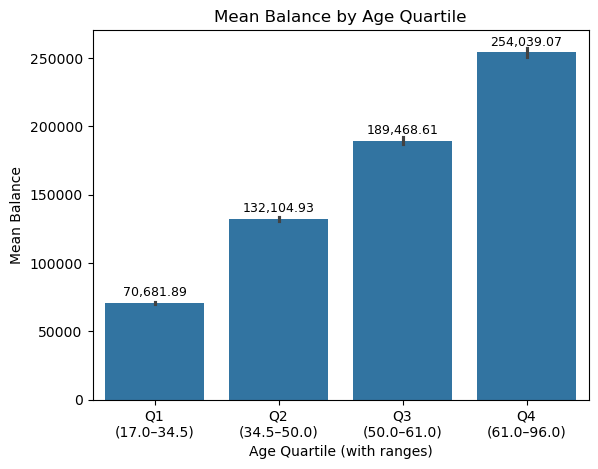

In [6]:
# Create age quartiles
quartiles, bins = pd.qcut(df["clnt_age"], 4, labels=["Q1", "Q2", "Q3", "Q4"], retbins=True)
df["age_quartile"] = quartiles
mean_bal_per_quartile = df.groupby("age_quartile")["bal"].mean().reset_index()

# Plot mean balance by age quartile
ax = sns.barplot(
    x="age_quartile",
    y="bal",
    data=df,
    estimator="mean",
    
)

# Replace tick labels with Q + age range
labels_with_ranges = [
    f"Q{i+1}\n({bins[i]:.1f}–{bins[i+1]:.1f})" for i in range(len(bins)-1)
]
ax.set_xticklabels(labels_with_ranges)

# Add mean balance values above bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=9, color='black',
        xytext=(0, 3), textcoords='offset points'
    )

# Labels and title
plt.xlabel("Age Quartile (with ranges)")
plt.ylabel("Mean Balance")
plt.title("Mean Balance by Age Quartile")
plt.show()

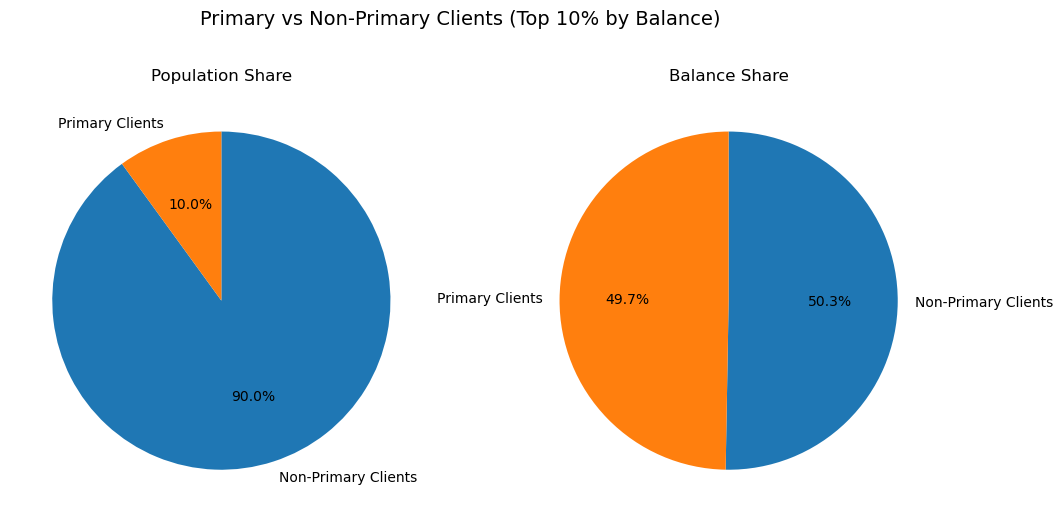

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# --- 1. Population share ---
pop_counts = df["primary_client"].value_counts()
axes[0].pie(
    pop_counts,
    labels=["Non-Primary Clients", "Primary Clients"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)
axes[0].set_title("Population Share")

# --- 2. Balance share ---
balance_share = df.groupby("primary_client")["bal"].sum()
axes[1].pie(
    balance_share,
    labels=["Non-Primary Clients", "Primary Clients"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)
axes[1].set_title("Balance Share")

plt.suptitle("Primary vs Non-Primary Clients (Top 10% by Balance)", fontsize=14)
plt.show()

#### 2.1 Age distribution for primary vs other clients <a id="age-distribution"></a>

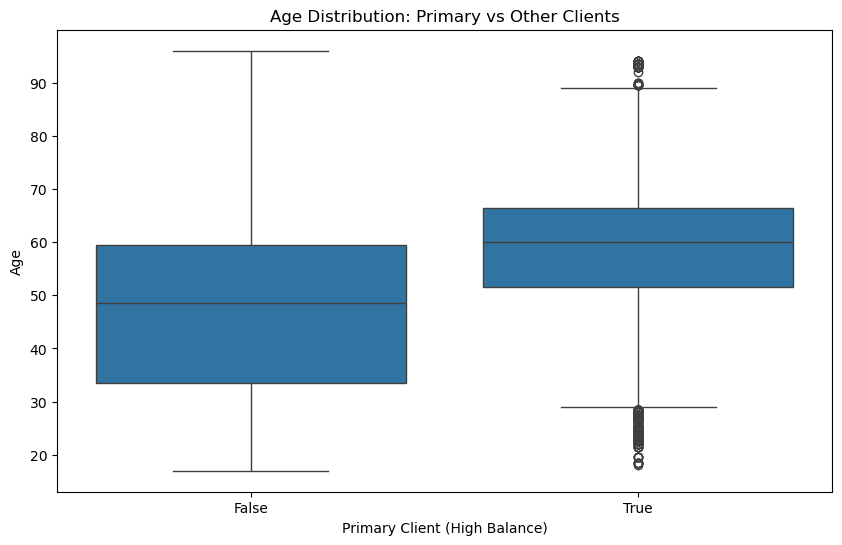

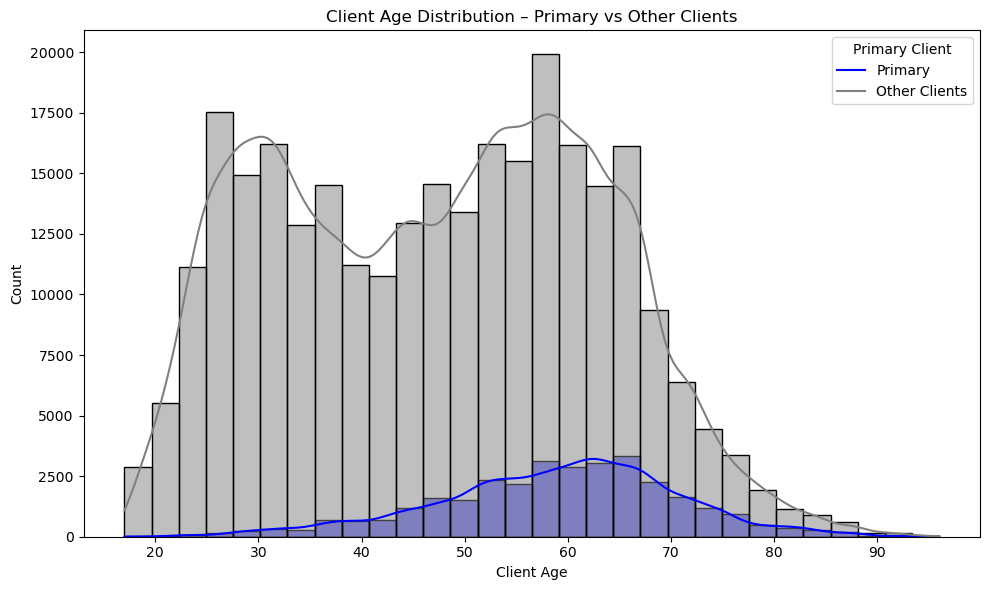

In [7]:
# Plot age distribution for primary vs other clients
plt.figure(figsize=(10, 6))
sns.boxplot(x="primary_client", y="clnt_age", data=df)
plt.xlabel("Primary Client (High Balance)")
plt.ylabel("Age")
plt.title("Age Distribution: Primary vs Other Clients")
plt.show()

# Overlayed age distribution histograms Primary vs Non-Primary
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="clnt_age", hue="primary_client", kde=True, palette={True: "blue", False: "gray"}, alpha=0.5, bins=30)

plt.title("Client Age Distribution – Primary vs Other Clients")
plt.xlabel("Client Age")
plt.ylabel("Count")
plt.legend(title="Primary Client", labels=["Primary", "Other Clients"])
plt.tight_layout()
plt.show()

#### 2.2 Tenure distribution for primary vs other clients <a id="tenure-distribution"></a>

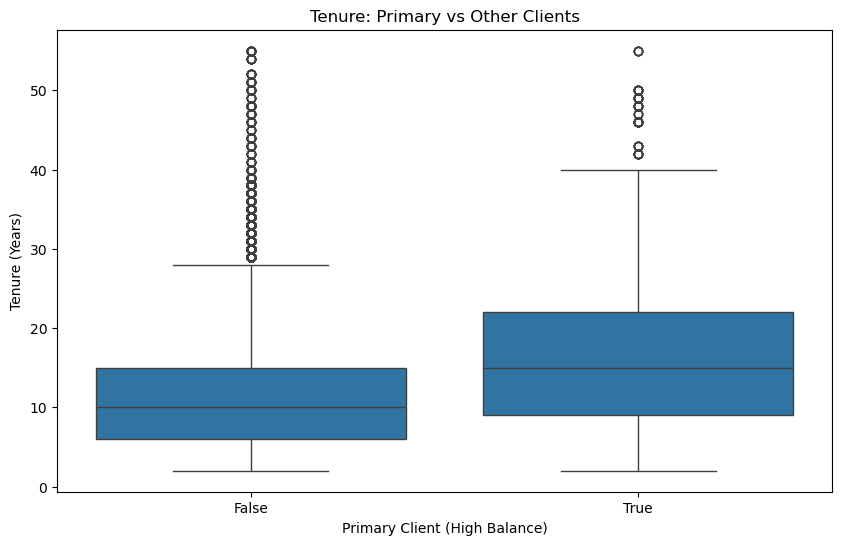

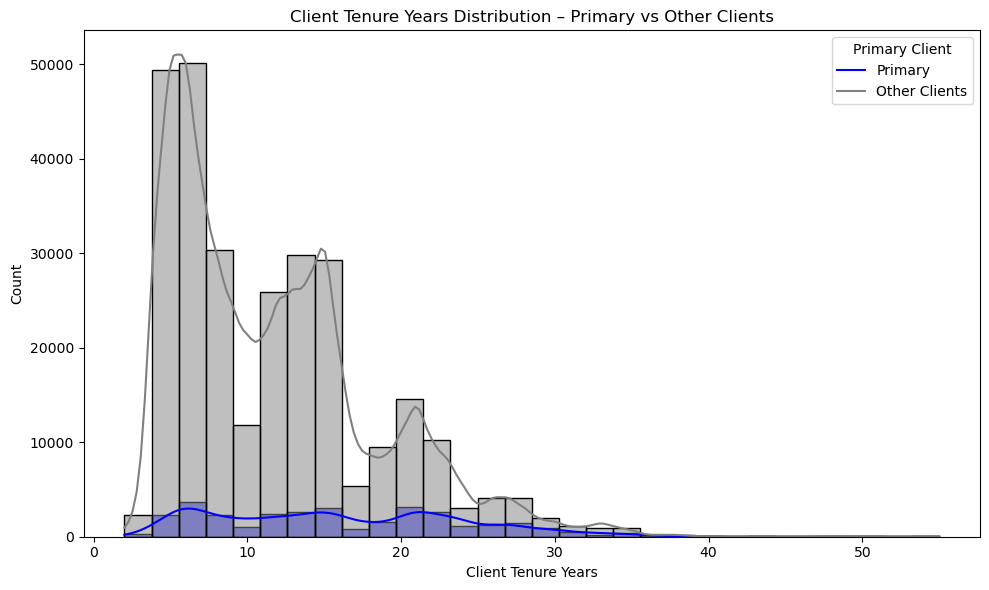

In [8]:
# Plot tenure distribution for primary vs other clients
plt.figure(figsize=(10, 6))
sns.boxplot(x="primary_client", y="clnt_tenure_yr", data=df)
plt.xlabel("Primary Client (High Balance)")
plt.ylabel("Tenure (Years)")
plt.title("Tenure: Primary vs Other Clients")
plt.show()

# Overlayed tenure distribution histograms Primary vs Non-Primary
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="clnt_tenure_yr", hue="primary_client", kde=True, palette={True: "blue", False: "gray"}, alpha=0.5, bins=30)

plt.title("Client Tenure Years Distribution – Primary vs Other Clients")
plt.xlabel("Client Tenure Years")
plt.ylabel("Count")
plt.legend(title="Primary Client", labels=["Primary", "Other Clients"])
plt.tight_layout()
plt.show()